In [ ]:

import os
import sys
sys.path.append('/home/agustin/phd/synthesis')
sys.path.append('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/utils')

import utils.nifti_functions as nfc
import utils.functions as fc
import utils.util as util

import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

# import prep_images as prep_images
from autoencoder_declaration import AutoencoderPrediction
from prep_image import prep_image


device_name = f"cuda:0"
device = torch.device(device_name)


In [13]:
def load_all_subject_resolutions(df, subject_id, modality, new_shape=None):
    subject_df = df[(df['sid'] == subject_id) & (df['modality'] == modality)]
    resolutions = subject_df['resolution'].unique()#[:1]
    
    images = {}
    affines = {}
    for res in resolutions:
        path = subject_df[subject_df['resolution'] == res]['org_img_path'].values[0]
        img, aff = nfc.load_nifti(path)

        if new_shape is not None:
            img, offset, new_aff = fc.resize_center_crop_pad(img, new_shape, aff)
            img = util.robust_normalize(img, percentile=(0,100), strictly_positive=True)
        


        images[res] = img
        affines[res] = aff
        # print(f"Loaded image with shape {img.shape} and resolution {res}")
    
    # new_shape = (368, 432, 368)

    return images, affines

In [14]:
df = pd.read_csv('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/csv/val_data.csv')
unique_ids = df['sid'].unique()
# modalities = df['modality'].unique()
# resolutions = df['resolution'].unique()

s_id = unique_ids[0]
modality = 'T1W'

imgs, affines = load_all_subject_resolutions(df, s_id, modality, new_shape = (384, 448, 384))
# imgs = load_all_subject_resolutions(df, s_id, modality, new_shape = (320, 384, 320))

# fc.imgshow_3D(imgs[0], name=f'{s_id} - {modality} - {ress[0]}')

In [ ]:
# # load_subject latent mask
# latent_mask_path = df[(df['subject_id'] == s_id) & (df['modality'] == modality) & (df['resolution'] == 7)]['latent_seg_mask'].values[0]
# latent_mask = np.load(latent_mask_path)
# latent_mask = np.where(latent_mask > 0, 1.0, 0.0)

# # dilate the mask
# from scipy.ndimage import binary_dilation
# from scipy.ndimage import gaussian_filter
# latent_mask_dilated = binary_dilation(latent_mask, iterations=5).astype(np.float32)
# latent_mask_gaussian = gaussian_filter(latent_mask_dilated, sigma=5)


# fc.imgshow_3D_list([latent_mask, latent_mask_dilated, latent_mask_gaussian], name=f'{s_id} - {modality} - Latent Mask')
# latent_mask = torch.from_numpy(latent_mask).unsqueeze(0).unsqueeze(0).float().to(device)

In [ ]:
autoencoder_chk_path = "/home/agustin/phd/BrainST/models/autoencoder/weights/autoencoder_epoch273.pt"
half = True
autoencoder = AutoencoderPrediction(autoencoder_chk_path, device, half=half)
latents = {}
reconstructions = {}
for i, (res, img) in enumerate(imgs.items()):
    print(f"Processing {s_id} - {modality} - {res}")
    latent = autoencoder.encode(img)
    # print(f"Latent shape: {latent.shape}")
    # latent *= latent_mask

    latents[res] = latent.cpu().squeeze().numpy()
    recon = autoencoder.decode(latent)
    reconstructions[res] = recon.cpu().squeeze().numpy()

    # save image 
    output_path = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/test1_vae/test_output"
    os.makedirs(output_path, exist_ok=True)
    img_postprocessed = prep_images.postprocess_img(recon.cpu().squeeze().numpy())
    nfc.save_nifti(os.path.join(output_path, f"{s_id}_{modality}_{res}_reconstruction.nii.gz"), recon.cpu().squeeze().numpy(), affines


Processing S001_GX - T1W - 0.1
Processing S001_GX - T1W - 1.5
Processing S001_GX - T1W - 3.0
Processing S001_GX - T1W - 5.0
Processing S001_GX - T1W - 7.0


In [6]:
# print latent shapes

for i, (res, latent) in enumerate(latents.items()):
    print(f"Resolution: {res}, Latent shape: {latent.shape}, img shape: {imgs[res].shape}")

Resolution: 0.1, Latent shape: (4, 80, 96, 80), img shape: (320, 384, 320)
Resolution: 1.5, Latent shape: (4, 80, 96, 80), img shape: (320, 384, 320)
Resolution: 3.0, Latent shape: (4, 80, 96, 80), img shape: (320, 384, 320)
Resolution: 5.0, Latent shape: (4, 80, 96, 80), img shape: (320, 384, 320)
Resolution: 7.0, Latent shape: (4, 80, 96, 80), img shape: (320, 384, 320)


In [7]:
# for i, res in enumerate(latents.keys()):
#     recon = reconstructions[res]
#     img = imgs[res]
#     mse_value = util.compute_mse(recon, img)
#     mae_value = util.compute_mae(recon, img)
#     ssim_value = util.compute_ssim(recon, img)
#     print(f"Rec vs Org -- Res: {res}, MSE: {mse_value:.4f}, MAE: {mae_value:.4f}, SSIM: {ssim_value:.4f}")
    
# # compute mse, mae and ssim between reconstructed resolutions and original 7T image
# for i, res in enumerate(latents.keys()):
#     recon = reconstructions[res]
#     img = imgs[7]
#     mse_value = util.compute_mse(recon, img)
#     mae_value = util.compute_mae(recon, img)
#     ssim_value = util.compute_ssim(recon, img)
#     print(f"Rec vs 7T Org -- Res: {res}T, MSE: {mse_value:.4f}, MAE: {mae_value:.4f}, SSIM: {ssim_value:.4f}")
    

# Rec vs Org -- Res: 0.1, MSE: 0.0001, MAE: 0.0046, SSIM: 0.9950
# Rec vs Org -- Res: 1.5, MSE: 0.0001, MAE: 0.0032, SSIM: 0.9924
# Rec vs Org -- Res: 3.0, MSE: 0.0001, MAE: 0.0045, SSIM: 0.9877
# Rec vs Org -- Res: 5.0, MSE: 0.0001, MAE: 0.0028, SSIM: 0.9890
# Rec vs Org -- Res: 7.0, MSE: 0.0000, MAE: 0.0023, SSIM: 0.9925
# Rec vs 7T Org -- Res: 0.1T, MSE: 0.0125, MAE: 0.0462, SSIM: 0.8795
# Rec vs 7T Org -- Res: 1.5T, MSE: 0.0057, MAE: 0.0295, SSIM: 0.9084
# Rec vs 7T Org -- Res: 3.0T, MSE: 0.0131, MAE: 0.0476, SSIM: 0.8969
# Rec vs 7T Org -- Res: 5.0T, MSE: 0.0010, MAE: 0.0116, SSIM: 0.9397
# Rec vs 7T Org -- Res: 7.0T, MSE: 0.0000, MAE: 0.0023, SSIM: 0.9925

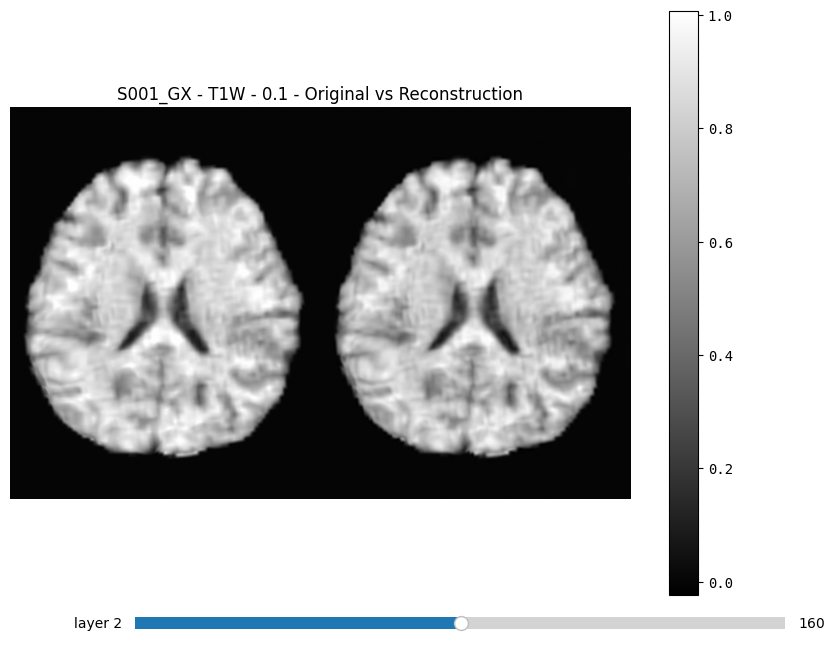

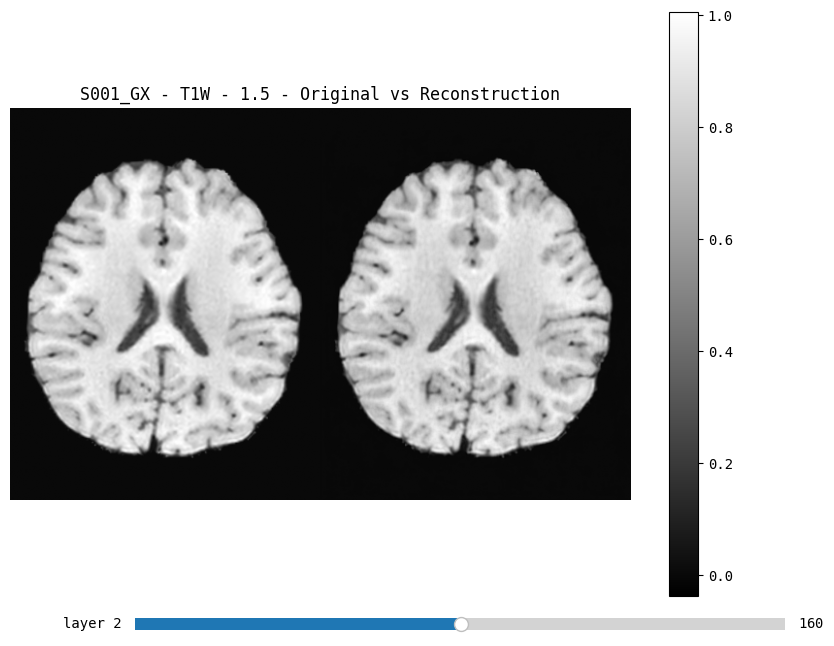

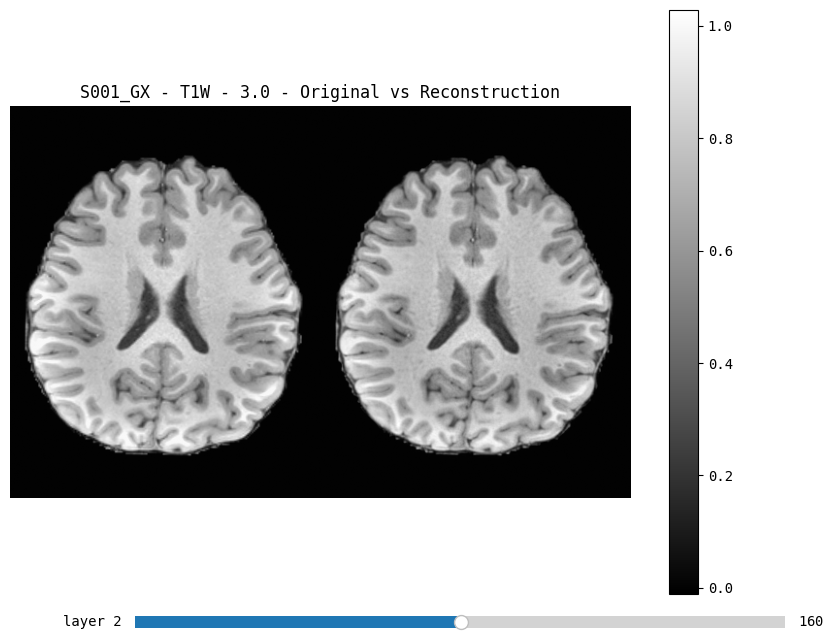

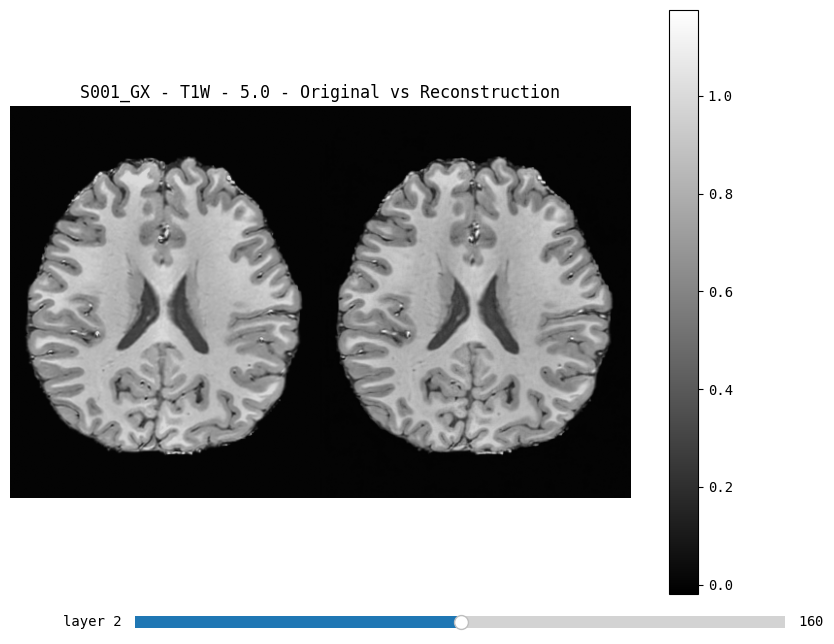

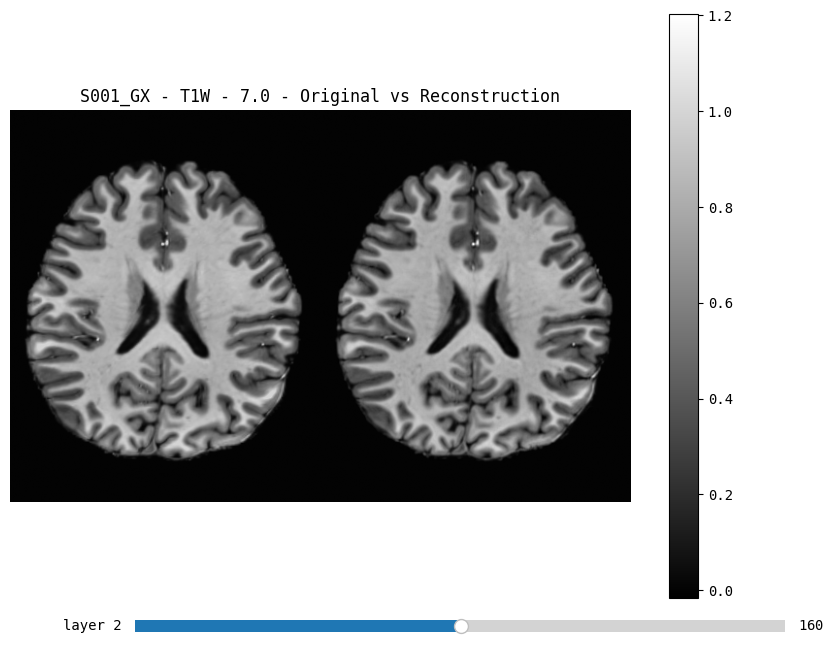

In [8]:
for i, res in enumerate(latents.keys()):
    fc.imgshow_3D_list([imgs[res], reconstructions[res]], name=f'{s_id} - {modality} - {res} - Original vs Reconstruction')

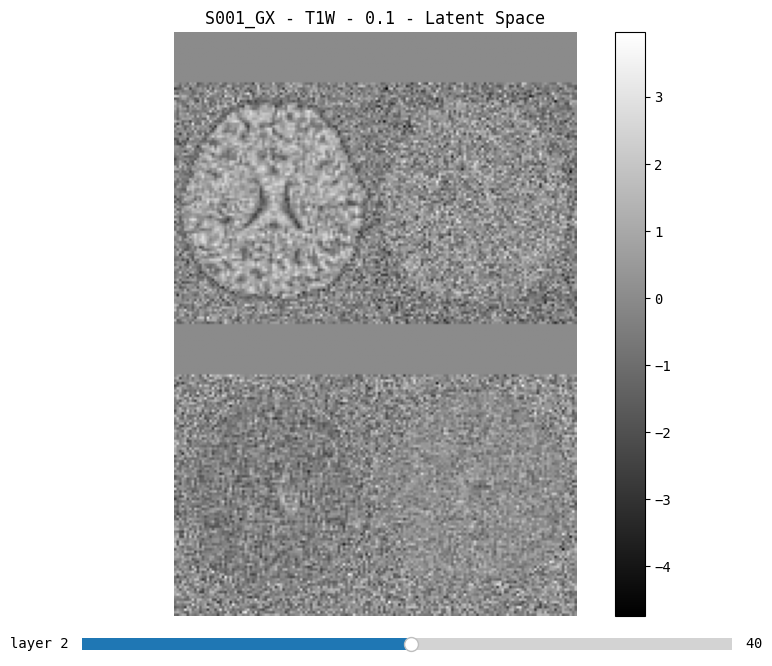

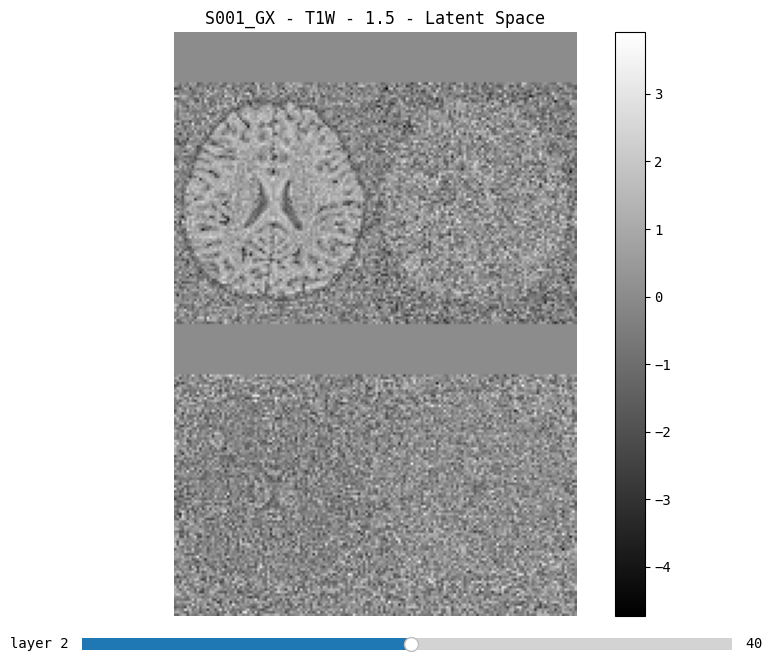

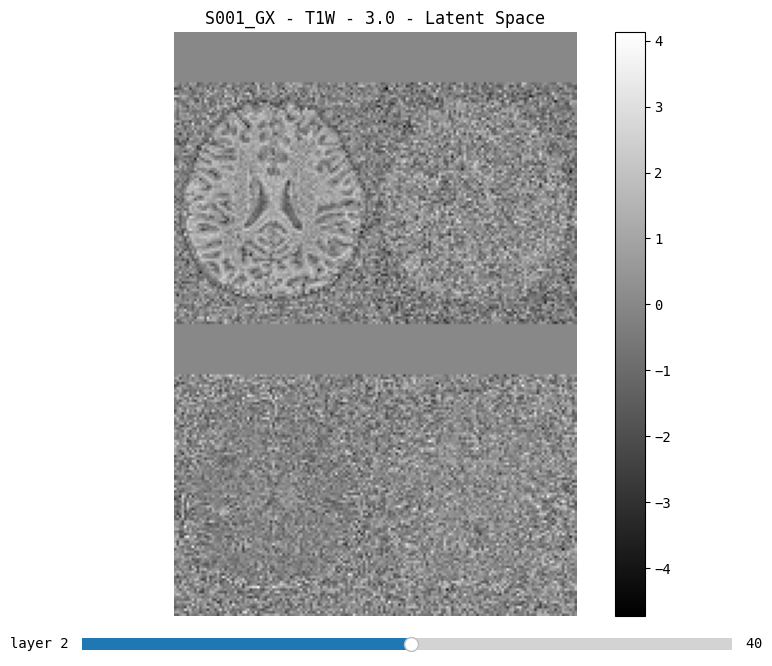

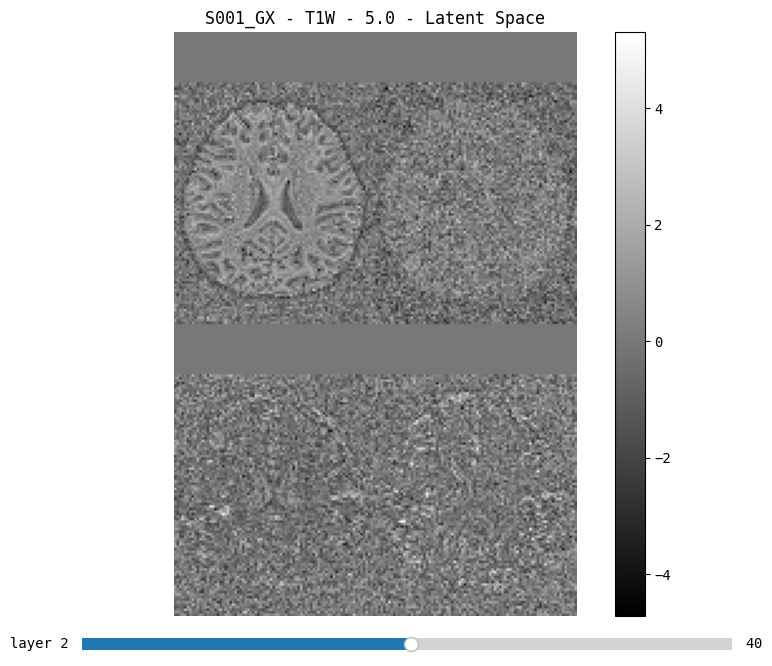

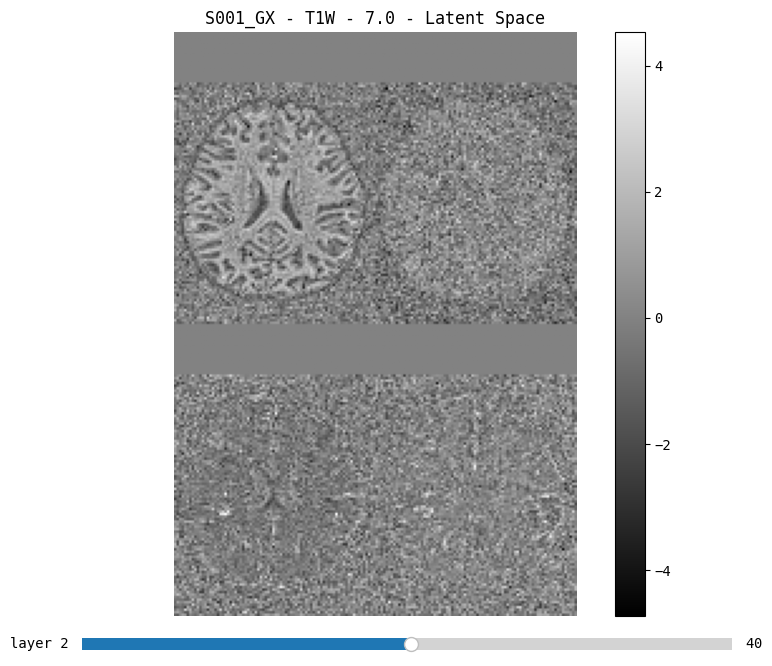

In [9]:
# visualize latents
for i, (res, latent) in enumerate(latents.items()):
    fc.imgshow_3D_list(latent, name=f'{s_id} - {modality} - {res} - Latent Space', )

min, max of img 7T: 0.0 1.0


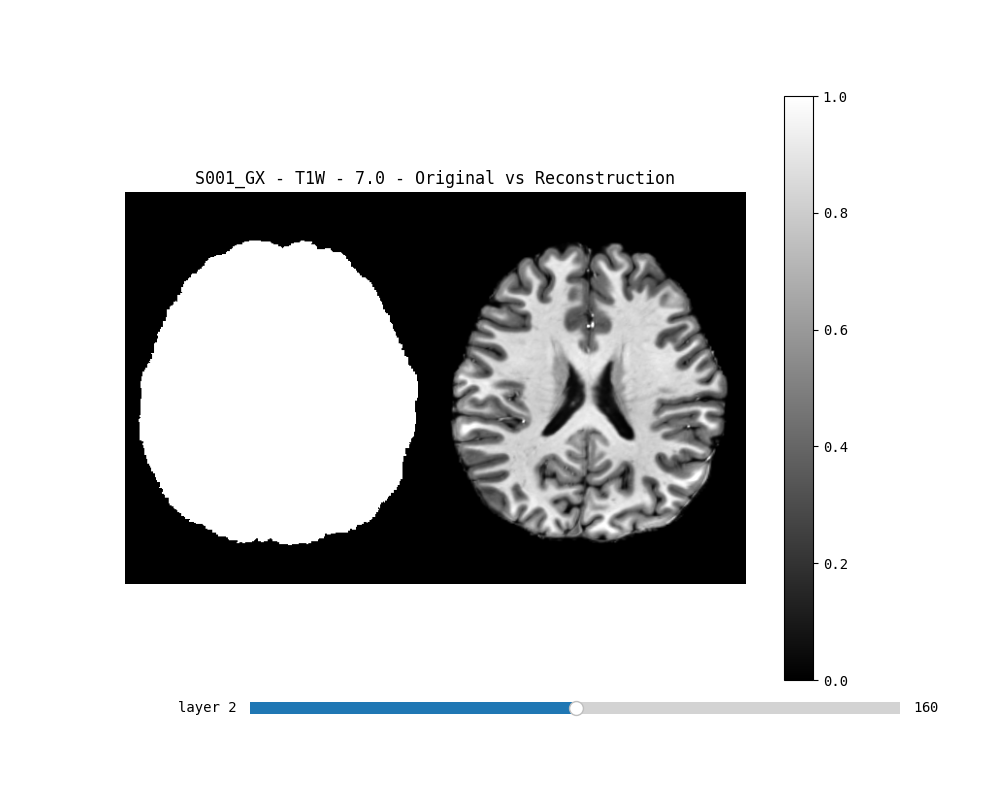

In [10]:
%matplotlib widget
brain_mask = np.where(imgs[7] > 0, 1, 0).astype(np.float32)
print("min, max of img 7T:", imgs[7].min(), imgs[7].max())
# disp_img = util.robust_normalize(imgs[7], percentile=(0.5,99.5), strictly_positive=True)
fc.imgshow_3D_list([brain_mask, imgs[7]], name=f'{s_id} - {modality} - {res} - Original vs Reconstruction')